<a href="https://colab.research.google.com/github/pdrdias/OpenLab-Projects/blob/main/Air_quality_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importações

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Activation


#Carregamento dos dados e análises preliminares

In [ ]:
dados = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AirQualityUCI.csv',sep = ';')

In [ ]:
dados.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

In [ ]:
dados

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Retirada das colunas que não agregam para a análise: Date e Time
dados.drop(columns=['Date','Time'],inplace = True)

In [ ]:
dados

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dados.drop(columns = ['Unnamed: 15','Unnamed: 16'], inplace = True)

In [ ]:
dados.value_counts(dropna = False)

CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  T     RH    AH    
NaN      NaN          NaN      NaN        NaN            NaN      NaN           NaN      NaN           NaN         NaN   NaN   NaN       114
-200    -200.0       -200.0    -200,0    -200.0         -200.0   -200.0        -200.0   -200.0        -200.0       -200  -200  -200       31
0,8     -200.0       -200.0    -200,0    -200.0         -200.0   -200.0        -200.0   -200.0        -200.0       -200  -200  -200        2
2,1      1327.0       256.0    9,8        971.0          124.0    803.0         89.0     1705.0        1120.0      21,6  41,7  1,0606      1
         1333.0      -200.0    10,3       989.0          129.0    885.0         121.0    1621.0        1194.0      14,5  57,8  0,9456      1
                                                                                                                                        ... 
0,9      948.0       -200.0    6,4        828.0          66.0     858.0         60.0     1711.0        994.0       24,4  55,2  1,6604      1
                      35.0     2,7        634.0          43.0     1320.0        61.0     1326.0        715.0       11,3  60,0  0,8025      1
                      93.0     4,0        710.0          56.0     1127.0        67.0     1352.0        575.0       15,7  45,9  0,8121      1
         949.0       -200.0    2,8        640.0          167.0    902.0         112.0    909.0         971.0       2,3   63,5  0,4630      1
         940.0       -200.0    5,9        806.0          181.0    800.0         48.0     1392.0        1013.0      16,2  76,9  1,4029      1
Name: count, Length: 9327, dtype: int64

In [ ]:
dados.shape

(9471, 13)

In [ ]:
dados.tail()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dados.isna().sum()

,0
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114
PT08.S4(NO2),114
PT08.S5(O3),114


In [ ]:
dados = dados.dropna()

In [ ]:
dados.isna().sum()
dados

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,"3,1",1314.0,-200.0,"13,5",1101.0,472.0,539.0,190.0,1374.0,1729.0,"21,9","29,3","0,7568"
9353,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"


In [ ]:
colunas = ['CO(GT)','C6H6(GT)','T', 'RH', 'AH']

dados[colunas] = dados[colunas].apply(
    lambda x: pd.to_numeric(
        x.astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )
)

/tmp/ipykernel_1029/3970873484.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados[colunas] = dados[colunas].apply(


In [ ]:
dados

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139


#Regressão linear

In [ ]:
#Assumindo o índice de qualidade sendo correspondente à coluna RH, segue tratativa para obtenção da regressão linear:
#Separando os conjuntos de treino e de teste:
train_dataset = dados.sample(frac=0.8,random_state=0)
test_dataset = dados.drop(train_dataset.index)
train_labels = train_dataset.pop('RH')
test_labels = test_dataset.pop('RH')

In [ ]:
#Obtendo algumas informações estatísticas acerca dos dados de treino e teste (média e desvio padrão):
train_stats = train_dataset.describe()
train_stats = train_stats.transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
CO(GT),7486.0,-34.287617,77.709461,-200.0,0.60000,1.5000,2.6000,11.900
PT08.S1(CO),7486.0,1046.254208,329.792940,-200.0,919.25000,1050.0000,1217.0000,2040.000
NMHC(GT),7486.0,-158.690756,140.800954,-200.0,-200.00000,-200.0000,-200.0000,1189.000
C6H6(GT),7486.0,1.717793,41.571183,-200.0,4.00000,7.8000,13.5750,52.100
PT08.S2(NMHC),7486.0,891.950040,342.325696,-200.0,708.25000,893.0000,1102.0000,2007.000
NOx(GT),7486.0,166.507881,256.091422,-200.0,49.00000,140.0000,282.0000,1479.000
PT08.S3(NOx),7486.0,797.553967,324.834524,-200.0,639.00000,797.0000,962.0000,2683.000
NO2(GT),7486.0,57.200641,127.148003,-200.0,53.00000,96.0000,132.0000,340.000
PT08.S4(NO2),7486.0,1388.307641,467.746917,-200.0,1180.00000,1445.0000,1661.0000,2775.000
PT08.S5(O3),7486.0,970.668982,456.662312,-200.0,697.00000,940.0000,1246.0000,2523.000


In [ ]:
#Normalizando os dados de treino e teste pela média e desvio padrão:

def norm(x):
  return (x - train_stats['mean']) / train_stats['std']
normed_train_data = norm(train_dataset)
normed_test_data = norm(test_dataset)

In [ ]:
#Definindo o modelo de regressão:
model = Sequential()
model.add(Dense(20, activation = 'tanh', input_shape = [len(train_dataset.keys())]))
model.add(Dense(20, activation = 'relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Definindo critérios de treinamento para o modelo de regressão:
model.compile(loss = 'mse', optimizer = tf.keras.optimizers.RMSprop(0.001), metrics = ['mae','mse'])

In [ ]:
print(normed_train_data.dtypes)

print(type(train_labels))
print(train_labels.dtype)

CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
AH               float64
dtype: object
<class 'pandas.core.series.Series'>
float64


In [ ]:
#Excutando o treinamento do modelo:
model.fit(normed_train_data, train_labels, epochs = 1000, validation_split = 0.2, verbose = 1)

Epoch 1/1000
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3694.3528 - mae: 50.7885 - mse: 3694.3528 - val_loss: 3509.2815 - val_mae: 47.2310 - val_mse: 3509.2815
Epoch 2/1000
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2511.9224 - mae: 36.5868 - mse: 2511.9224 - val_loss: 2012.8990 - val_mae: 28.0729 - val_mse: 2012.8990
Epoch 3/1000
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1387.2161 - mae: 21.5923 - mse: 1387.2161 - val_loss: 1313.8646 - val_mae: 19.7074 - val_mse: 1313.8646
Epoch 4/1000
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 954.2253 - mae: 17.3463 - mse: 954.2253 - val_loss: 887.4786 - val_mae: 16.5000 - val_mse: 887.4786
Epoch 5/1000
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 600.1869 - mae: 14.3190 - mse: 600.1869 - val_loss: 496.5433 - val_mae: 13.0836 - val_mse: 496.5433
Epoch 6/1000
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 306.5892 - mae: 11.0946 - mse: 306.5892 - val_loss: 207.8057 - val_mae: 9.6450 - val_mse: 207.8057
Epoch 7/1000
188/

#Avaliando o modelo com os dados de treino:

In [ ]:
model.evaluate(normed_test_data, test_labels, verbose = 1)

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1662 - mae: 0.9526 - mse: 2.1662


[2.166154384613037, 0.9526243805885315, 2.166154384613037]

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


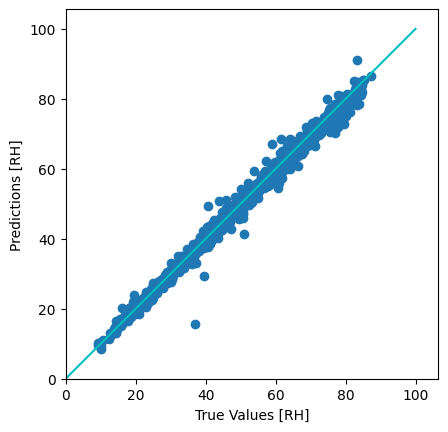

In [ ]:
#Análise gráfica:
test_predictions = model.predict(normed_test_data).flatten()
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [RH]')
plt.ylabel('Predictions [RH]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100],'c')